## Feature selection for Cu-Pb-Zn from stream sediment samples 
- Trace element data is log transformed 
- Trace and major data both are standardized
- Feature selection is carried out based on PCA and Correlation matrix

In [13]:
#Loading a dataset into a dataframe 
from sklearn.decomposition import PCA
import pandas as pd 
df = pd.read_csv('sss_raj.csv') 
print(df)

      SiO2    Al2O3   Fe2O3   MnO   MgO   CaO   Na2O   K2O   TiO2   P2O5   \
0      61.13   11.83    7.40  0.11  3.03  3.63   2.13  1.26   1.24   0.10   
1      64.87   12.18    7.06  0.09  2.44  3.17   2.01  1.75   0.96   0.13   
2      61.92   11.02    7.64  0.10  3.80  4.17   1.51  1.90   1.05   0.21   
3      63.72   11.34    7.46  0.10  3.00  4.02   1.88  1.55   1.04   0.15   
4      59.55   13.22    7.33  0.10  3.52  3.33   1.56  2.43   0.99   0.17   
...      ...     ...     ...   ...   ...   ...    ...   ...    ...    ...   
3430   57.02   15.65    6.13  0.08  2.69  1.97   0.51  2.35   0.90   0.09   
3431   52.75   15.11    5.69  0.07  3.35  4.92   0.70  2.12   0.78   0.16   
3432   50.03   12.70    5.11  0.07  2.90  9.54   0.78  1.70   0.79   0.12   
3433   52.61   14.58    5.99  0.06  3.36  5.50   0.73  1.33   0.83   0.10   
3434   55.72   14.55    5.91  0.05  3.10  4.24   0.50  1.49   0.87   0.09   

      ...     Eu       Gd    Tb       Dy      Ho       Er      Tm     Yb   

In [14]:
#splitting Major oxide and trace element 
#log transform trace and combining Major+trace dataframe 
#Joining both then carrying out standaradization
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Step 1: Load the CSV files into DataFrames
df_major = pd.read_csv('sss_raj_major.csv')  # Replace with your CSV file path
df_trace = pd.read_csv('sss_raj_trace.csv')  # Replace with your CSV file path

# Step 2: Log transform the trace element data
# Apply log1p transformation to the trace data to handle zero values
df_trace_log = df_trace.copy()
df_trace_log = df_trace_log.apply(np.log1p)  # Apply log1p to all columns in the trace DataFrame

# Step 3: Concatenate the major and log-transformed trace DataFrames
df_combined = pd.concat([df_major, df_trace_log], axis=1)

# Step 4: Apply StandardScaler to the combined DataFrame
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df_combined), columns=df_combined.columns)

print("Original Major DataFrame:")
print(df_major.head())
print("\nLog-Transformed Trace DataFrame:")
print(df_trace_log.head())
print("\nCombined DataFrame:")
print(df_combined.head())
print("\nStandardized DataFrame:")
print(df_scaled.head())
df_scaled.to_csv('sss_log_scaled.csv')

Original Major DataFrame:
   SiO2    Al2O3   Fe2O3   MnO   MgO   CaO   Na2O   K2O   TiO2   P2O5 
0   61.13   11.83    7.40  0.11  3.03  3.63   2.13  1.26   1.24   0.10
1   64.87   12.18    7.06  0.09  2.44  3.17   2.01  1.75   0.96   0.13
2   61.92   11.02    7.64  0.10  3.80  4.17   1.51  1.90   1.05   0.21
3   63.72   11.34    7.46  0.10  3.00  4.02   1.88  1.55   1.04   0.15
4   59.55   13.22    7.33  0.10  3.52  3.33   1.56  2.43   0.99   0.17

Log-Transformed Trace DataFrame:
        Ba        Ga       Sc          V        Th        Pb        Ni   \
0  5.680173  3.091042  2.639057  4.653960  2.197225  2.890372  4.499810   
1  6.006353  2.944439  2.564949  4.564348  2.302585  3.091042  4.158883   
2  5.998937  2.890372  2.564949  4.700480  2.397895  3.091042  4.543295   
3  5.789960  2.944439  2.639057  4.709530  2.079442  3.135494  4.262680   
4  5.866468  3.044522  2.772589  4.691348  2.397895  2.944439  3.970292   

        Co       Rb         Sr   ...        Gd       Tb        

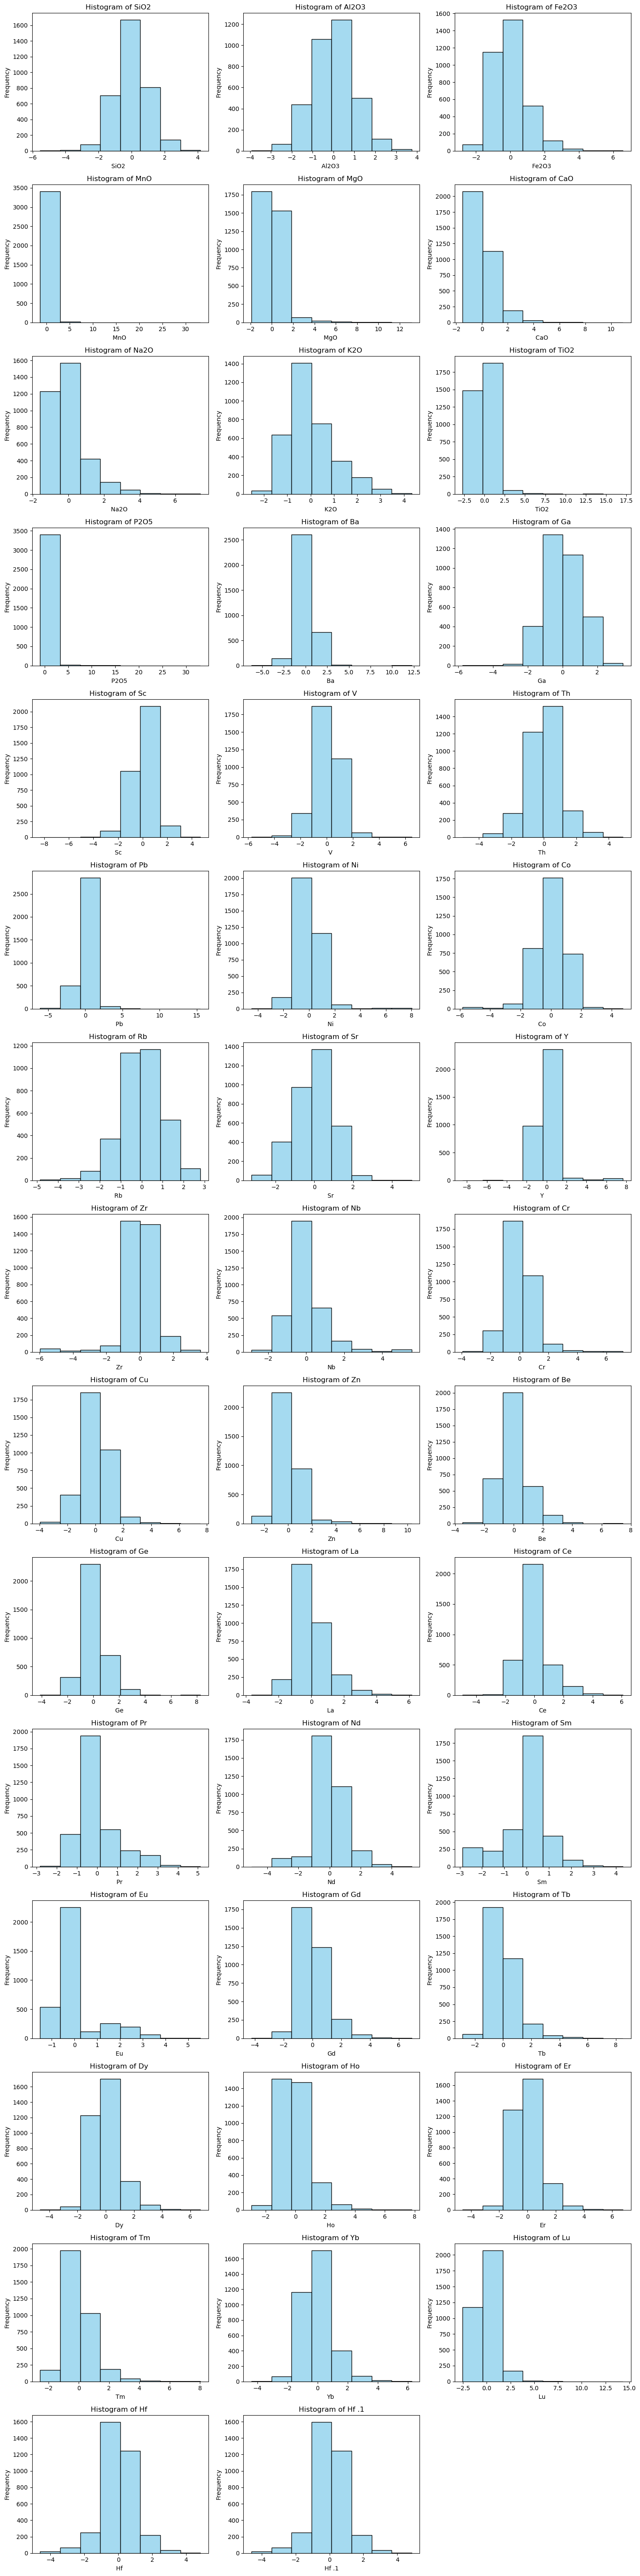

In [15]:
#histogram generation of each element 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Assume df_scaled is your DataFrame
num_columns = len(df_scaled.columns)

# Determine the grid size (adjust rows and cols as needed)
rows = int(np.ceil(num_columns / 3))  # 3 columns per row
cols = 3

# Create subplots
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))  # Adjust figure size

# Flatten axes array for easy indexing
axes = axes.flatten()

# Plot histograms on each subplot
for i, column in enumerate(df_scaled.columns):
    sns.histplot(df_scaled[column], bins=8, kde=False, color='skyblue', ax=axes[i])
    axes[i].set_title(f'Histogram of {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Frequency')

# Remove any unused subplots (if num_columns isn't a perfect multiple of cols)
for j in range(i + 1, rows * cols):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()

# Save the figure with all histograms
plt.savefig('Histograms_All.png', format='png', bbox_inches='tight')
plt.show()


          SiO2      Al2O3     Fe2O3       MnO       MgO       CaO      Na2O   \
SiO2    1.000000 -0.274013 -0.459923 -0.088065 -0.427313 -0.483562 -0.181950   
Al2O3  -0.274013  1.000000  0.163923 -0.048009 -0.109874 -0.407256  0.162820   
Fe2O3  -0.459923  0.163923  1.000000  0.381737  0.499017  0.000446 -0.006805   
MnO    -0.088065 -0.048009  0.381737  1.000000  0.178462 -0.006530 -0.069270   
MgO    -0.427313 -0.109874  0.499017  0.178462  1.000000  0.199127  0.021949   
CaO    -0.483562 -0.407256  0.000446 -0.006530  0.199127  1.000000  0.062256   
Na2O   -0.181950  0.162820 -0.006805 -0.069270  0.021949  0.062256  1.000000   
K2O     0.131802  0.555265 -0.249018 -0.125850 -0.220938 -0.424944 -0.164763   
TiO2   -0.237832  0.041259  0.562067  0.214735  0.041220  0.012726 -0.045628   
P2O5   -0.110341 -0.029080  0.064459  0.148935  0.091701  0.147929 -0.018476   
Ba     -0.032417  0.266372 -0.049392  0.012332 -0.079831 -0.187404  0.027993   
Ga      0.025648  0.394263  0.278936  0.

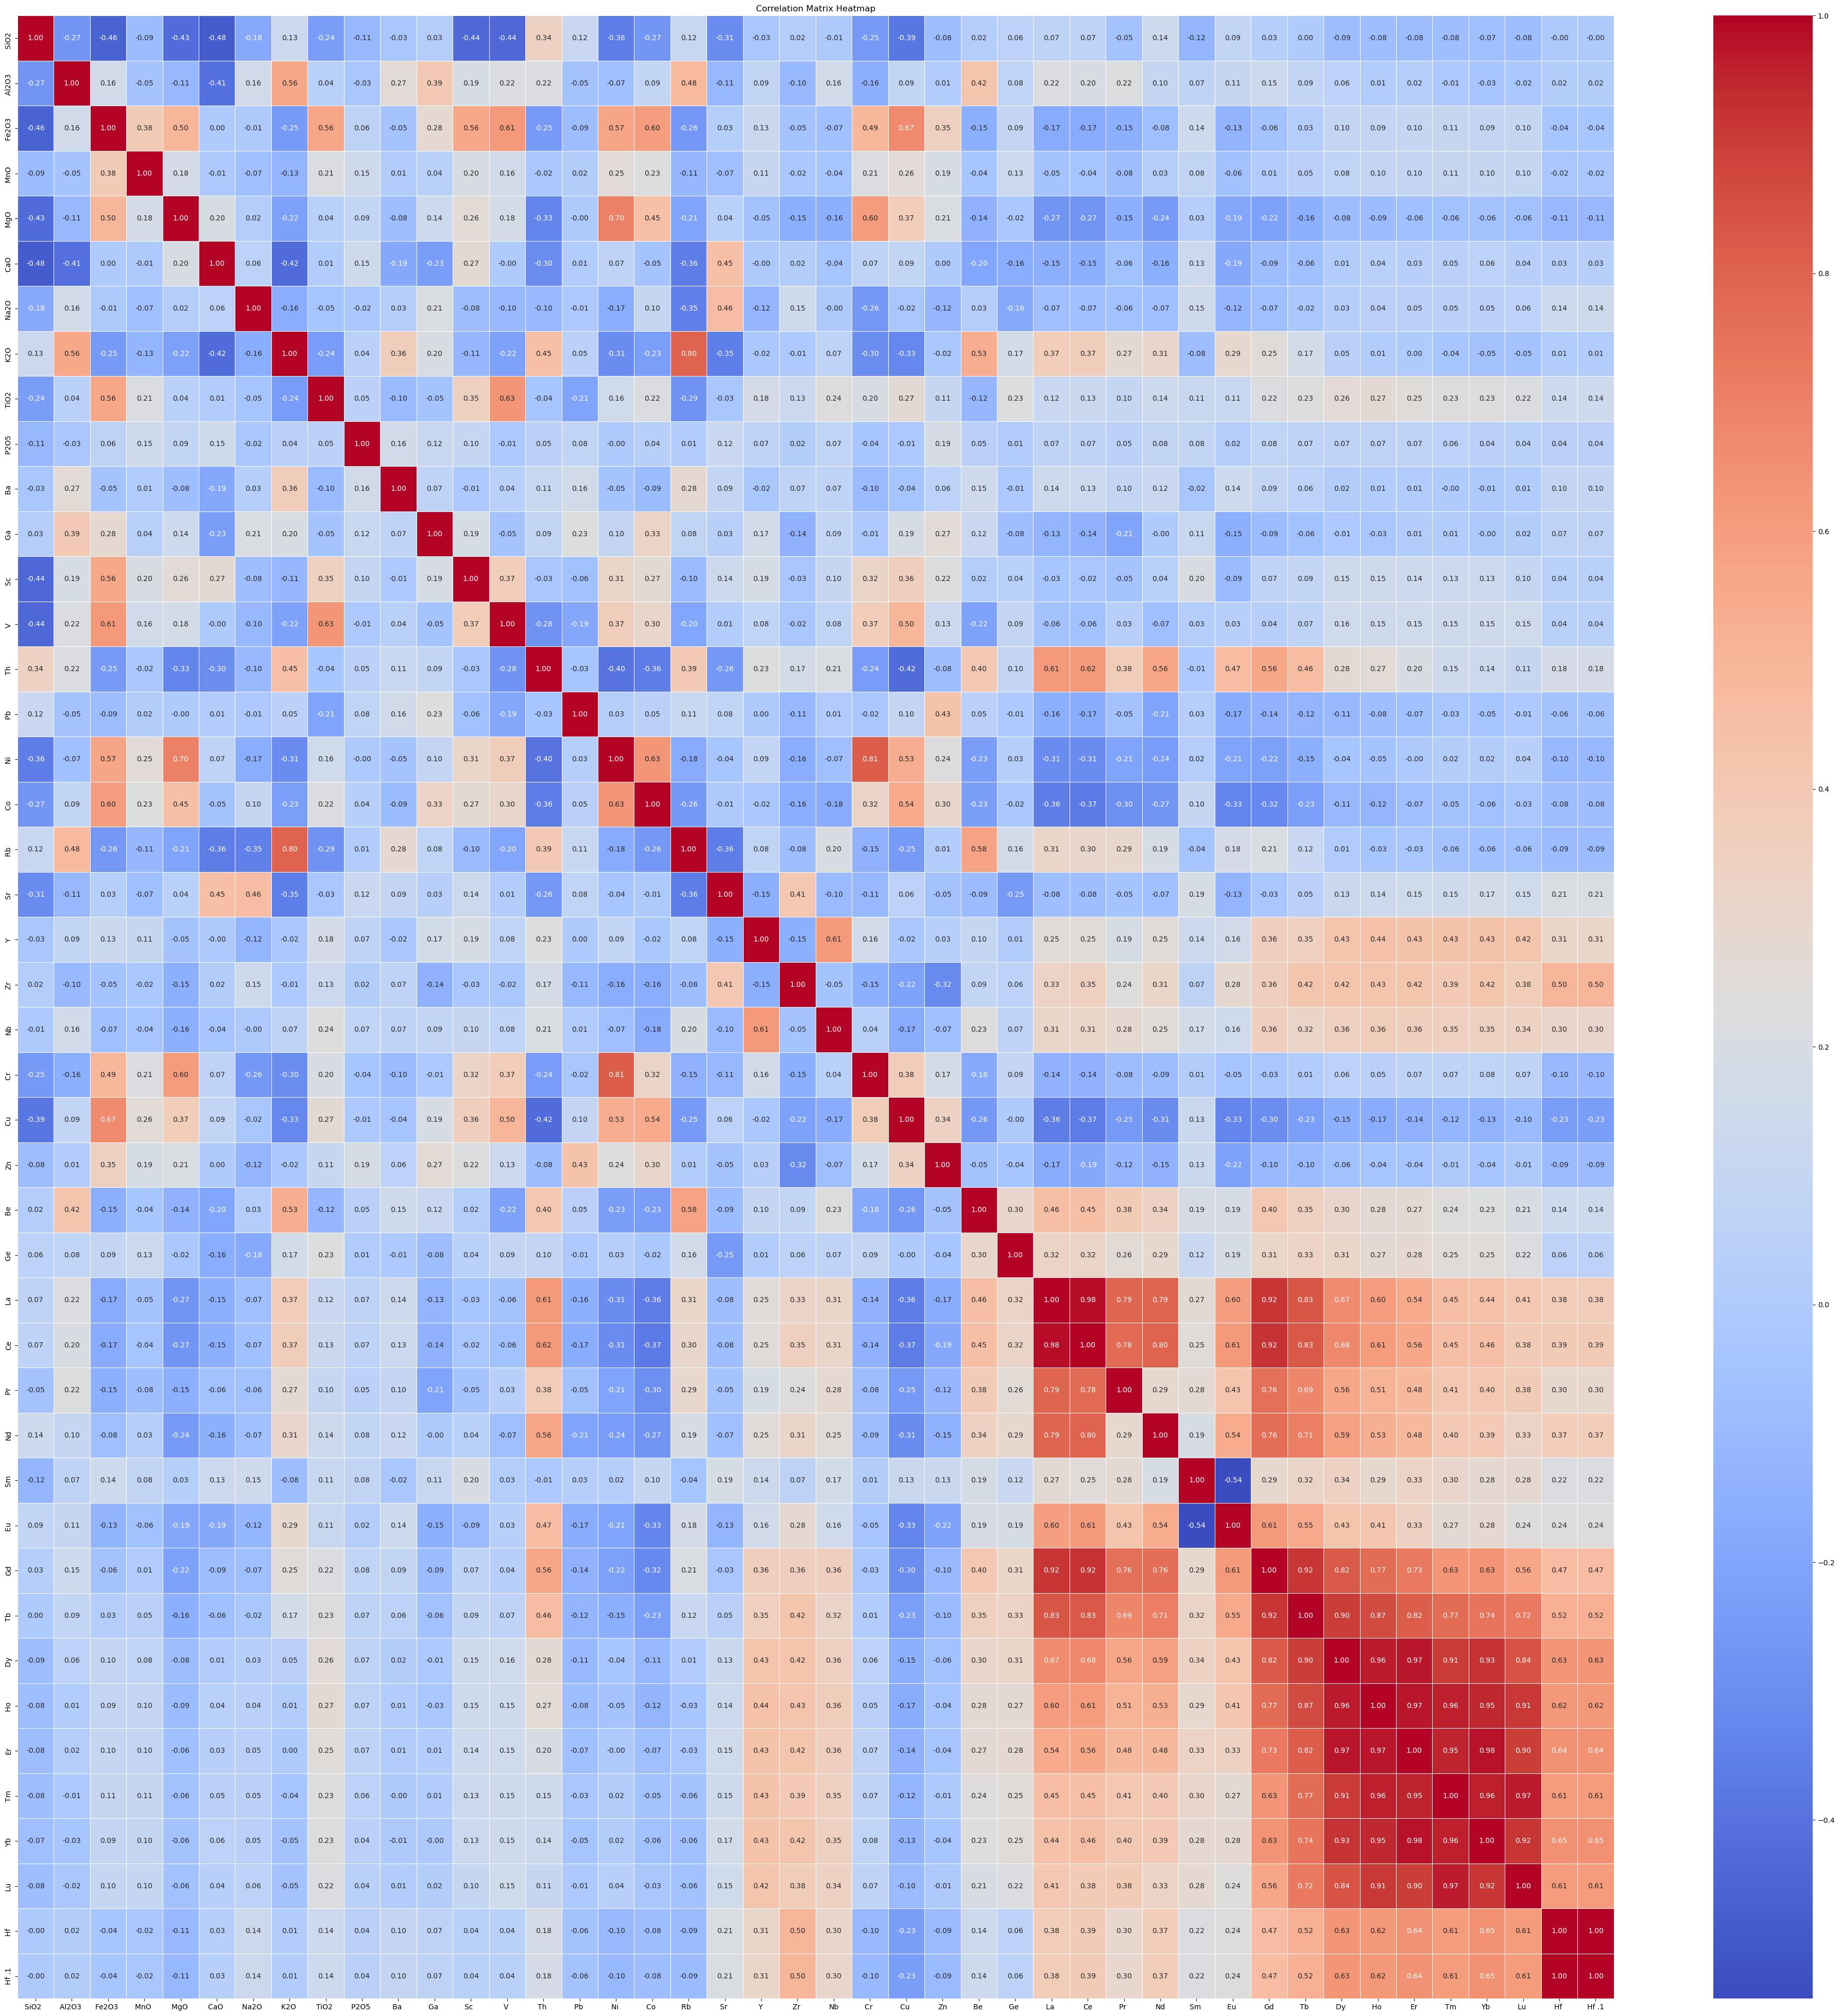

In [16]:
#Finding a corrleation matrix to search for elements in correlation with Cu, Pb, Zn
#standarized data has no affect on correlation matrix 
corr_matrix = df_scaled.corr()
print(corr_matrix)
import seaborn as sns
plt.figure(figsize=(50, 50))  # Adjust the size as needed
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')
plt.savefig('Log_corr.png', format='png', bbox_inches='tight')
plt.show()
plt.close()


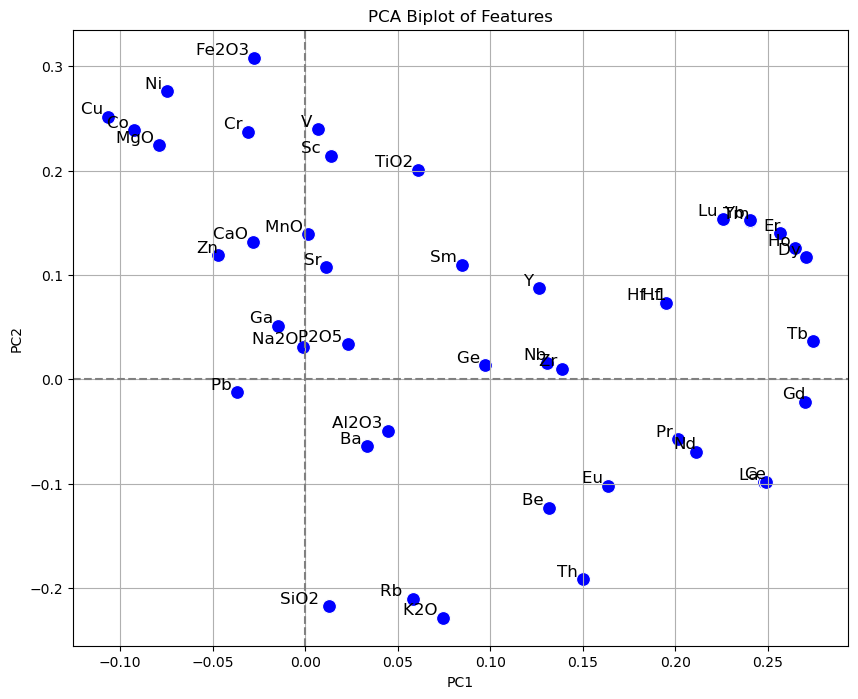

In [17]:
#Apply PCA for dimensionality 
# Feature selection
from sklearn.decomposition import PCA
pca = PCA(n_components=2)  # Reduce to 2 components for visualization
pca_components = pca.fit_transform(df_scaled)
pca_loadings = pca.components_.T  # Loadings for the features

# Create a DataFrame for PCA loadings
pca_loadings_df = pd.DataFrame(pca_loadings, columns=['PC1', 'PC2'], index=df_scaled.columns)

# Plot PCA results with feature loadings
plt.figure(figsize=(10, 8))
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
sns.scatterplot(data=pca_loadings_df, x='PC1', y='PC2', s=100, color='blue')

# Add feature labels
for feature in pca_loadings_df.index:
    plt.text(pca_loadings_df.loc[feature, 'PC1'], pca_loadings_df.loc[feature, 'PC2'], feature,
             fontsize=12, ha='right', va='bottom')

# Add titles and labels
plt.title('PCA Biplot of Features')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.savefig('PCA.png', format='png', bbox_inches='tight')
plt.show()
plt.close()


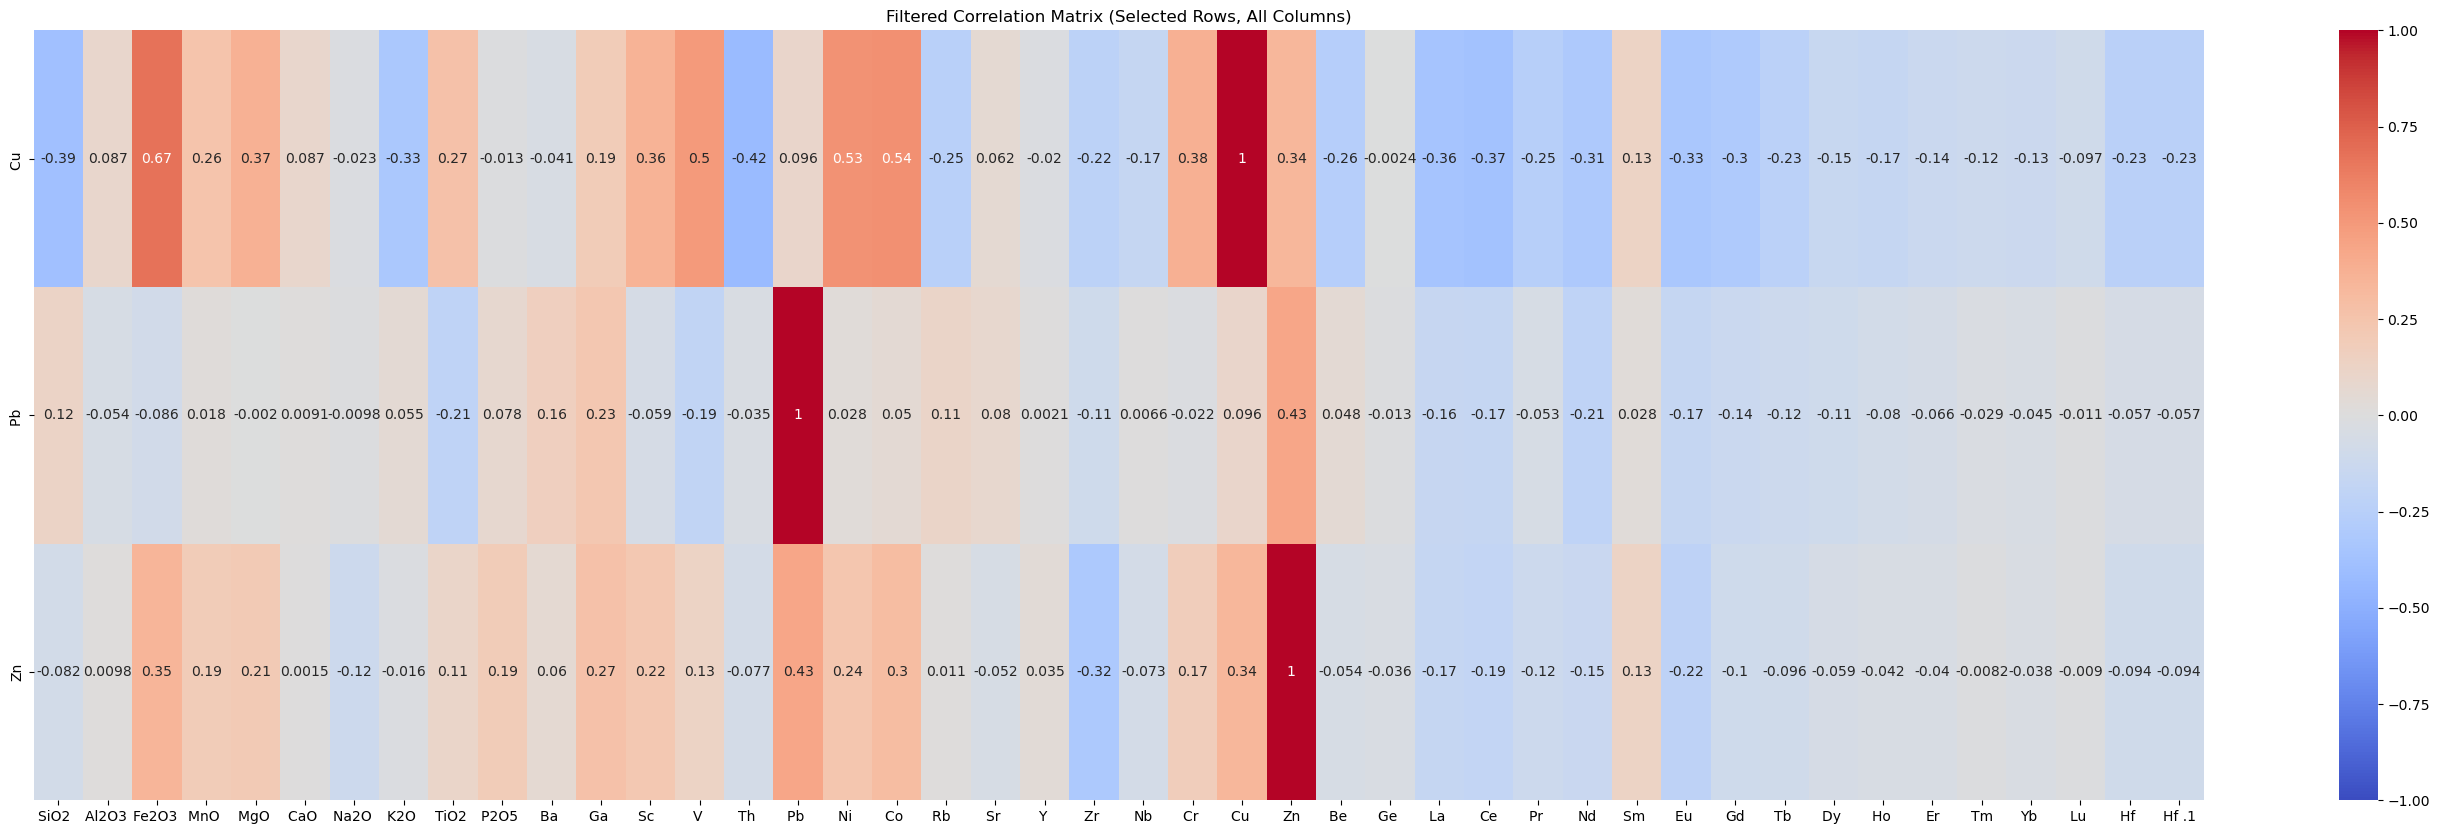

In [18]:
# Step 2: Filter specific rows (14, 23, 24) and keep all columns
filtered_corr = corr_matrix.iloc[[24, 15, 25], :]

# Step 3: Plot the filtered correlation matrix
plt.figure(figsize=(35, 10))
sns.heatmap(filtered_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Filtered Correlation Matrix (Selected Rows, All Columns)')
plt.savefig('Filtered_Corr.png', format='png', bbox_inches='tight')
plt.show()

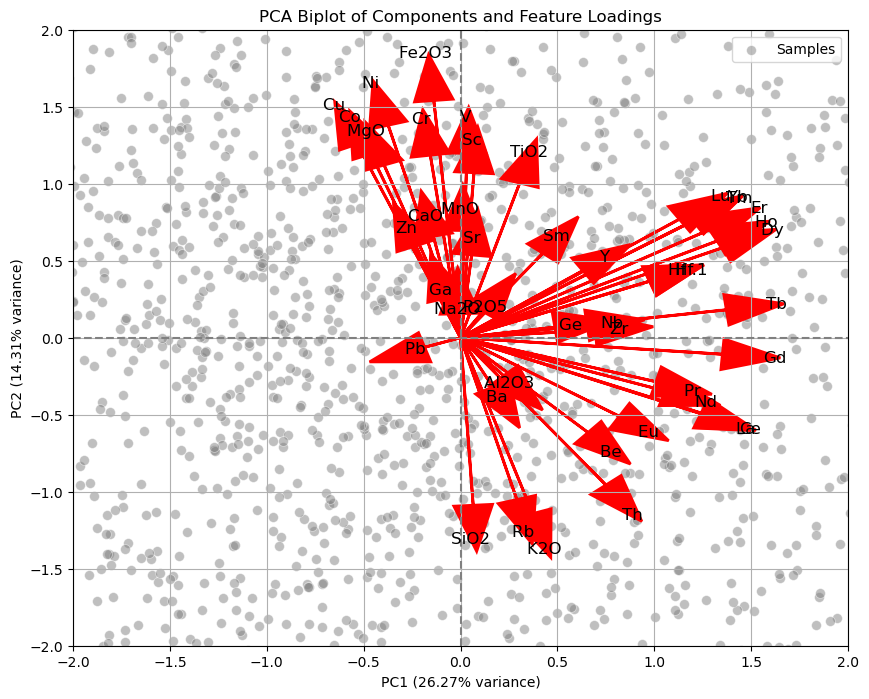

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA

# Step 1: Apply PCA to your scaled DataFrame
pca = PCA(n_components=2)  # Reduce to 2 components for visualization
pca_components = pca.fit_transform(df_scaled)  # Transformed data (scores)
pca_loadings = pca.components_.T  # Loadings for the features

# Step 2: Create DataFrame for PCA loadings and transformed data
pca_loadings_df = pd.DataFrame(pca_loadings, columns=['PC1', 'PC2'], index=df_scaled.columns)
pca_components_df = pd.DataFrame(pca_components, columns=['PC1', 'PC2'])

# Step 3: Plot PCA results with both components (scores) and loadings
plt.figure(figsize=(10, 8))

# Plot the PCA-transformed data points (scores)
sns.scatterplot(data=pca_components_df, x='PC1', y='PC2', s=50, color='grey', alpha=0.5, label='Samples')

# Step 4: Scale feature loadings for better visibility
loading_scale = 5  # Increase or decrease this value to scale vectors
for feature in pca_loadings_df.index:
    plt.arrow(0, 0, pca_loadings_df.loc[feature, 'PC1'] * loading_scale, pca_loadings_df.loc[feature, 'PC2'] * loading_scale,
              color='red', head_width=0.2, head_length=0.3, linewidth=2)
    plt.text(pca_loadings_df.loc[feature, 'PC1'] * loading_scale * 1.2, pca_loadings_df.loc[feature, 'PC2'] * loading_scale * 1.2, feature,
             color='black', ha='center', va='center', fontsize=12)

# Step 5: Set axis limits
plt.xlim(-2, 2)
plt.ylim(-2, 2)

# Step 6: Add titles, labels, and grid
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.title('PCA Biplot of Components and Feature Loadings')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.grid(True)

# Save and show the plot
plt.savefig('PCA_Biplot_Limited_Axis.png', format='png', bbox_inches='tight')
plt.show()


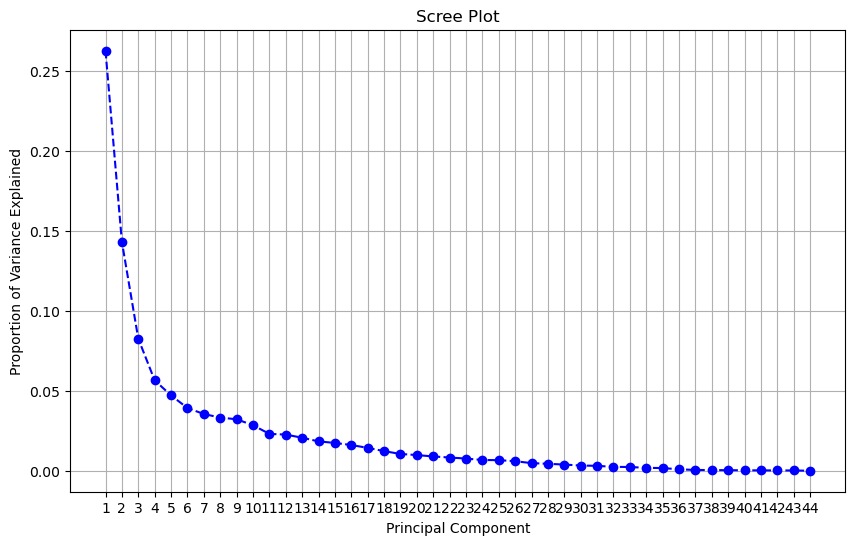

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA

# Step 1: Apply PCA to your scaled DataFrame
pca = PCA()  # Fit without reducing components to get all eigenvalues
pca.fit(df_scaled)

# Step 2: Get explained variance
explained_variance = pca.explained_variance_ratio_

# Step 3: Create the scree plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='--', color='b')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Proportion of Variance Explained')
plt.xticks(range(1, len(explained_variance) + 1))
plt.grid(True)


# Save and show the plot
plt.savefig('Scree_Plot.png', format='png', bbox_inches='tight')
plt.show()


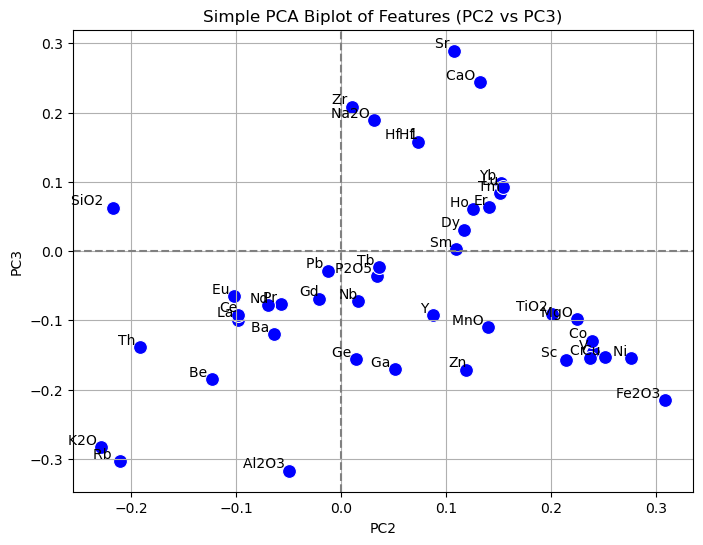

In [21]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.decomposition import PCA
import seaborn as sns

# Step 1: Apply PCA to your scaled DataFrame
pca = PCA(n_components=3)  # We need at least 3 components for PC2 and PC3
pca.fit(df_scaled)

# Step 2: Get PCA loadings
pca_loadings = pca.components_.T  # Loadings for the features

# Step 3: Create DataFrame for PCA loadings
pca_loadings_df = pd.DataFrame(pca_loadings, columns=['PC1', 'PC2', 'PC3'], index=df_scaled.columns)

# Step 4: Create a simple biplot for PC2 and PC3
plt.figure(figsize=(8, 6))

# Plot the feature loadings for PC2 and PC3
sns.scatterplot(x=pca_loadings_df['PC2'], y=pca_loadings_df['PC3'], color='blue', s=100)

# Add feature labels
for feature in pca_loadings_df.index:
    plt.text(pca_loadings_df.loc[feature, 'PC2'], pca_loadings_df.loc[feature, 'PC3'], feature,
             fontsize=10, ha='right', va='bottom')

# Add titles and labels
plt.title('Simple PCA Biplot of Features (PC2 vs PC3)')
plt.xlabel('PC2')
plt.ylabel('PC3')
plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.grid()

# Show the plot
plt.show()



In [22]:
# Check for NaN values
print(df_scaled.isna().sum())  # Count of NaN values per column

# Check for infinite values
print(np.isinf(df_scaled).sum())  # Count of infinite values per column

SiO2      0
Al2O3     0
Fe2O3     0
MnO       0
MgO       0
CaO       0
Na2O      0
K2O       0
TiO2      0
P2O5      0
Ba        0
Ga        0
Sc        0
V         0
Th        0
Pb        0
Ni        0
Co        0
Rb        0
Sr        0
Y         0
Zr        0
Nb        0
Cr        0
Cu        0
Zn        0
Be        0
Ge        0
La        0
Ce        0
Pr        0
Nd        0
Sm        0
Eu        0
Gd        0
Tb        0
Dy        0
Ho        0
Er        0
Tm        0
Yb        0
Lu        0
Hf        0
Hf .1     0
dtype: int64
SiO2      0
Al2O3     0
Fe2O3     0
MnO       0
MgO       0
CaO       0
Na2O      0
K2O       0
TiO2      0
P2O5      0
Ba        0
Ga        0
Sc        0
V         0
Th        0
Pb        0
Ni        0
Co        0
Rb        0
Sr        0
Y         0
Zr        0
Nb        0
Cr        0
Cu        0
Zn        0
Be        0
Ge        0
La        0
Ce        0
Pr        0
Nd        0
Sm        0
Eu        0
Gd        0
Tb        0
Dy        0
Ho        0
Er 